# 02. Multilingual Domain Classification: Model Assessment

This notebook evaluates the performance of the fine-tuned NLP transformer model (`DistilBERT-multilingual-cased`) used to categorize job postings into four primary domains: **IT, Finance, HR, and Other**. 

Specifically, this analysis addresses the following research questions:
1. *Can multilingual job postings be reliably classified into domain categories using NLP techniques?*
2. *What classification accuracy can be achieved across English, German, and Polish job descriptions using a single multilingual transformer model without prior translation?*

We will assess the model using standard classification metrics (Accuracy, Precision, Recall, F1-Score) and visualize the results using Confusion Matrices both overall and stratified by language.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

## 1. Load Validation Data

To evaluate the model, we use the held-out validation dataset containing the true labels (ground truth) and the labels predicted by our fine-tuned multilingual model. The dataset includes postings from global platforms (English), StepStone.de (German), and Pracuj.pl (Polish).

In [2]:
import pandas as pd
import torch
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = r"C:\Users\olegv\labor_research-1\models\domain_classifier"
TEST_FILE = r"C:\Users\olegv\labor_research-1\data\processed\held_out_set_labeled.csv"

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
OUTPUT_FILE = os.path.join(BASE_DIR, "data", "processed", "validation_results.csv")

print("1. loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computations will be performed on: {device}")
model.to(device)
model.eval()

print(f"2. loading test dataset ({TEST_FILE})...")
df_test = pd.read_csv(TEST_FILE)

text_col = 'description'
label_col = 'label' if 'label' in df_test.columns else 'true_label' if 'true_label' in df_test.columns else df_test.columns[2]

df_test = df_test.dropna(subset=[text_col, label_col])
texts = df_test[text_col].tolist()

print(f"3. generating predictions for {len(texts)} job postings...")
predictions = []
batch_size = 16 

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
        predictions.extend(batch_preds)

id2label = model.config.id2label
df_test['predicted_label'] = [id2label[pred] for pred in predictions]

df_test = df_test.rename(columns={label_col: 'true_label'})

print(f"4. saving results to {OUTPUT_FILE}...")

df_test.to_csv(OUTPUT_FILE, index=False)
print("Done")

c:\Users\olegv\labor_research-1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. loading model and tokenizer...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1935.24it/s]


Computations will be performed on: cpu
2. loading test dataset (C:\Users\olegv\labor_research-1\data\processed\held_out_set_labeled.csv)...
3. generating predictions for 300 job postings...
4. saving results to c:\Users\olegv\labor_research-1\data\processed\validation_results.csv...
Done


In [3]:
VALIDATION_FILE = os.path.join(BASE_DIR, "data", "processed", "validation_results.csv")

try:
    df_val = pd.read_csv(VALIDATION_FILE)
    print(f"Validation dataset loaded successfully. Total records: {len(df_val)}")
    display(df_val.head())
except FileNotFoundError:
    print(f"Error: File {VALIDATION_FILE} not found.")

Validation dataset loaded successfully. Total records: 300


,title,company,description,true_label,Unnamed: 4,predicted_label
0,Software Engineering-Cloud Engineer Full Stack...,JPMorgan Chase & Co.,About this job Job type: Full-time Role: Full ...,IT,NaN,IT
1,Softwareentwickler (m/w/d) Backend – Java / COBOL,ING-DiBa AG,About this job Job type: Full-time Experience ...,IT,NaN,IT
2,"AVP, Strategic Projects Senior Business Analyst",DBS Bank Limited,"AVP, Strategic Projects Senior Business Analys...",Finance,NaN,Finance
3,Node js developer,UNIFY TECHNOLOGIES,About this job Job type: Full-time Technologie...,IT,NaN,IT
4,Scala developer opportunity at Equal Experts P...,Equal Experts,About this job Job type: Full-time Experience ...,IT,NaN,IT


## 2. Overall Model Performance

First, we calculate the aggregated performance metrics across all languages to answer the primary question regarding the overall reliability of the NLP classification pipeline.

In [6]:
df_val['true_label'] = df_val['true_label'].astype(str).str.strip()
df_val['predicted_label'] = df_val['predicted_label'].astype(str).str.strip()

actual_labels = sorted(list(set(df_val['true_label'].unique()) | set(df_val['predicted_label'].unique())))
print(f"Classes in the dataset: {actual_labels}\n")

overall_accuracy = accuracy_score(df_val['true_label'], df_val['predicted_label'])
overall_f1 = f1_score(df_val['true_label'], df_val['predicted_label'], average='weighted')

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Weighted F1-Score: {overall_f1:.4f}\n")

print("Detailed Classification Report (All Languages):")
print("-" * 55)
print(classification_report(
    df_val['true_label'], 
    df_val['predicted_label'], 
    labels=actual_labels, 
    target_names=actual_labels, 
    zero_division=0
))

Classes in the dataset: ['Finance', 'HR', 'IT', 'Other']

Overall Accuracy: 0.6933
Overall Weighted F1-Score: 0.7533

Detailed Classification Report (All Languages):
-------------------------------------------------------
              precision    recall  f1-score   support

     Finance       0.55      0.82      0.66        57
          HR       0.00      0.00      0.00         2
          IT       0.99      0.72      0.83       217
       Other       0.62      0.21      0.31        24

    accuracy                           0.69       300
   macro avg       0.54      0.44      0.45       300
weighted avg       0.87      0.69      0.75       300



## 3. Performance by Language (English vs. German vs. Polish)

A core challenge of this project is handling multilingual text without the computational overhead of translation. Here, we stratify the classification metrics by language to ensure the model does not exhibit severe performance degradation on non-English texts.

In [8]:
%pip install langdetect

from langdetect import detect
import pandas as pd

def safe_detect_language(text):
    try:
        lang = detect(str(text))
        
        if lang == 'en': return 'EN'
        elif lang == 'de': return 'DE'
        elif lang == 'pl': return 'PL'
        else: return 'Other_Lang'
    except:
        return 'Unknown'

df_val['language'] = df_val['description'].apply(safe_detect_language)

print(df_val['language'].value_counts())


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached langdetect-1.0.9-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.
language
EN            229
DE             44
Other_Lang     17
PL             10
Name: count, dtype: int64


In [9]:
languages = df_val['language'].unique()

language_metrics = []

for lang in languages:
    df_subset = df_val[df_val['language'] == lang]
    
    acc = accuracy_score(df_subset['true_label'], df_subset['predicted_label'])
    f1 = f1_score(df_subset['true_label'], df_subset['predicted_label'], average='weighted', zero_division=0)
    
    language_metrics.append({'Language': lang, 'Accuracy': acc, 'Weighted F1': f1, 'Sample Size': len(df_subset)})
    
    print(f"\nClassification Report for Language: {lang} (N={len(df_subset)})")
    print("-" * 55)
    print(classification_report(df_subset['true_label'], df_subset['predicted_label'], zero_division=0))

metrics_df = pd.DataFrame(language_metrics).sort_values(by='Weighted F1', ascending=False)
print("\n\033[1mSummary of Performance Across Languages:\033[0m")
display(metrics_df)


Classification Report for Language: EN (N=229)
-------------------------------------------------------
              precision    recall  f1-score   support

     Finance       0.52      0.95      0.67        44
          HR       0.00      0.00      0.00         2
          IT       0.99      0.75      0.85       177
       Other       0.00      0.00      0.00         6

    accuracy                           0.76       229
   macro avg       0.38      0.43      0.38       229
weighted avg       0.87      0.76      0.79       229


Classification Report for Language: DE (N=44)
-------------------------------------------------------
              precision    recall  f1-score   support

     Finance       1.00      0.17      0.29         6
          HR       0.00      0.00      0.00         0
          IT       1.00      0.41      0.58        22
       Other       0.83      0.31      0.45        16

    accuracy                           0.34        44
   macro avg       0.71      0.2

,Language,Accuracy,Weighted F1,Sample Size
3,Other_Lang,1.000000,1.000000,17
0,EN,0.759825,0.787351,229
1,DE,0.340909,0.494573,44
2,PL,0.200000,0.285714,10


## 4. Confusion Matrices

To better understand where the model struggles (e.g., confusing Finance with HR), we visualize the confusion matrices. This helps identify structural overlaps in the domain vocabularies.

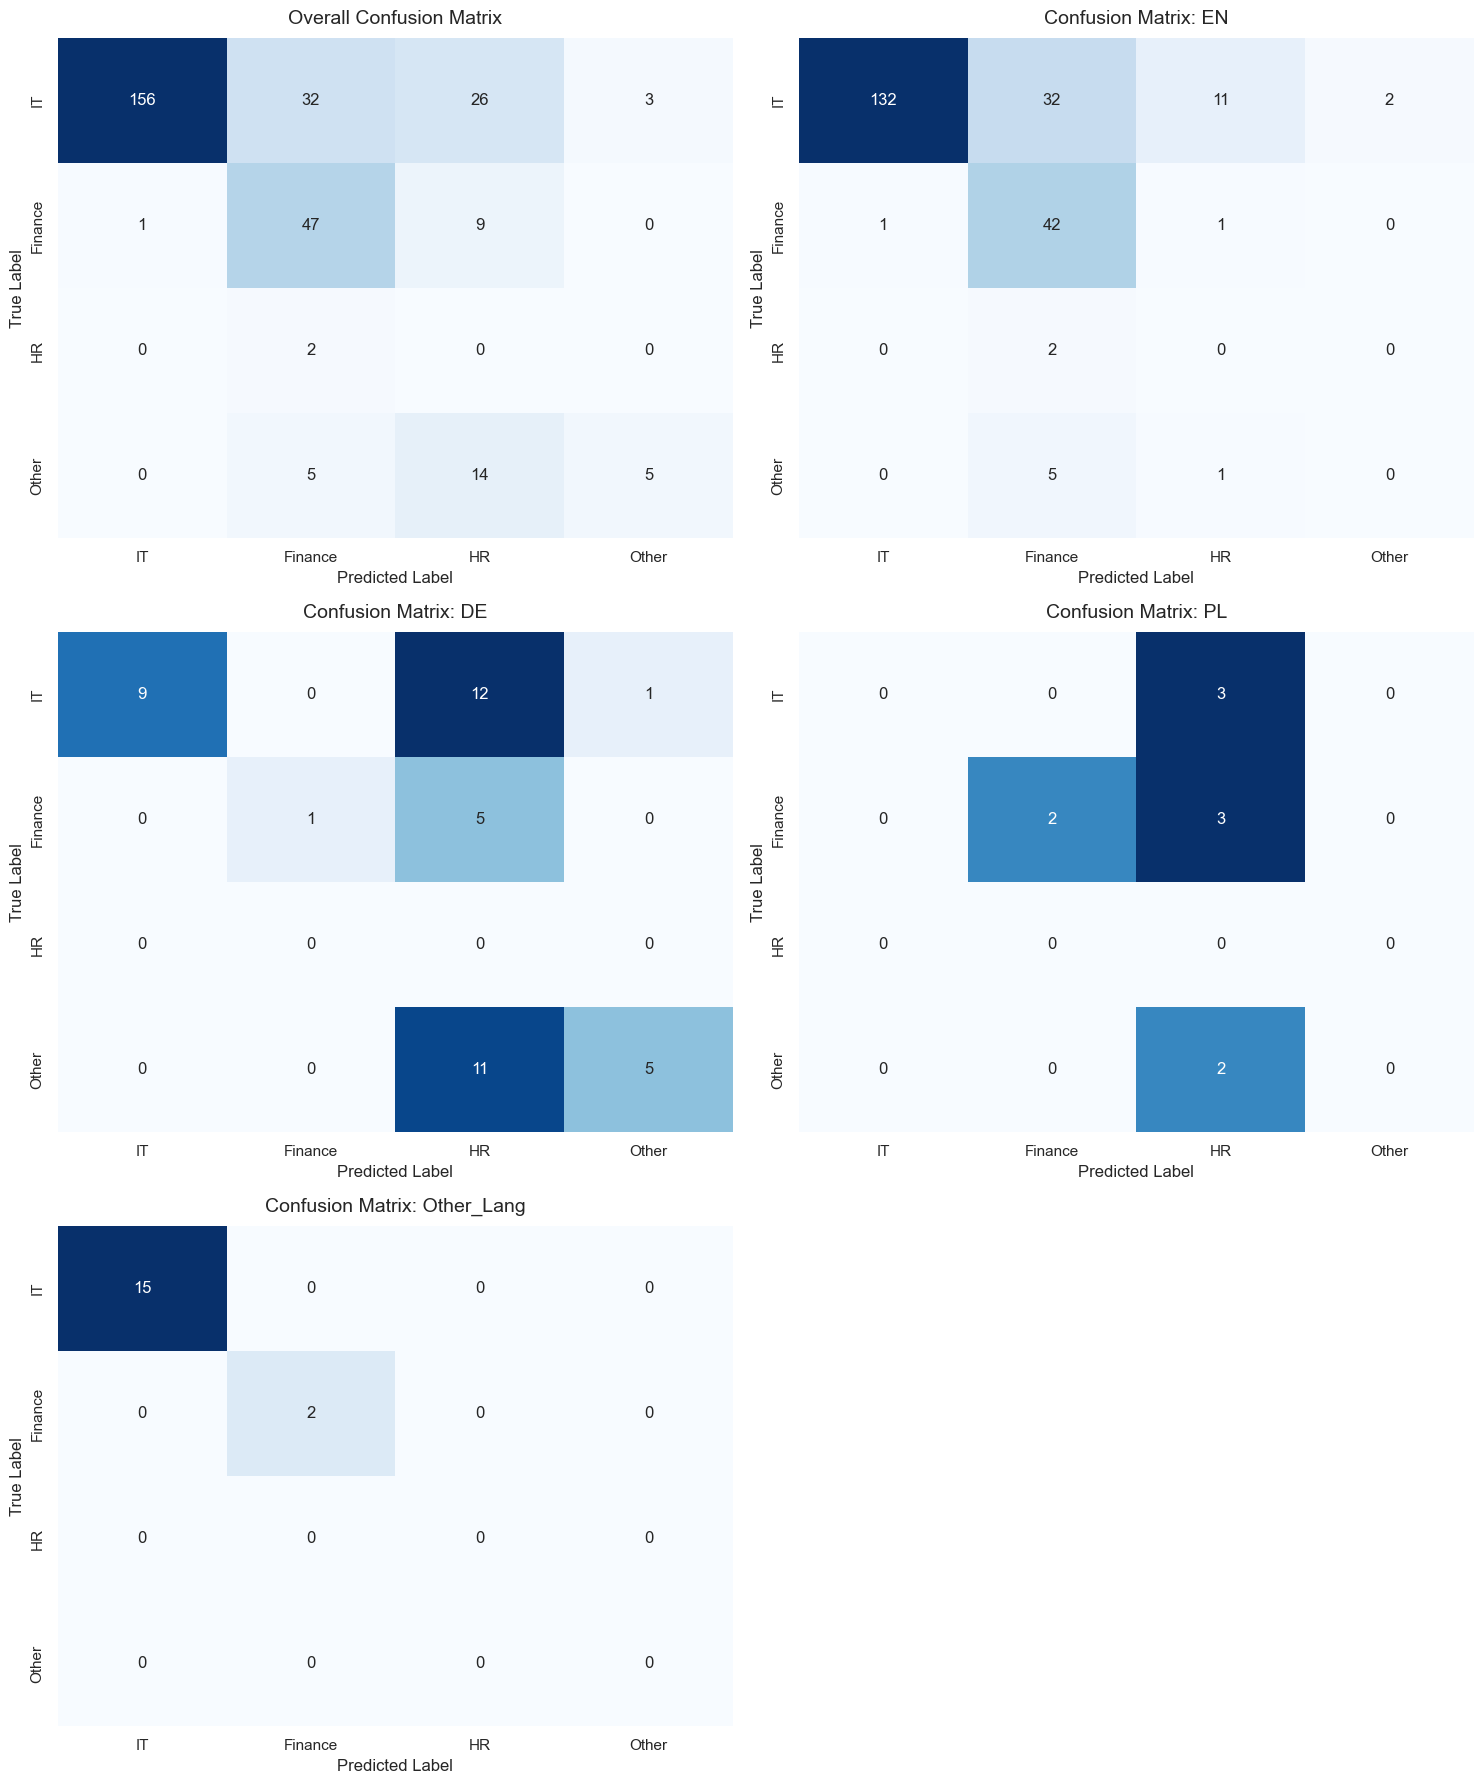

In [10]:
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

num_plots = len(languages) + 1
cols = 2
rows = (num_plots + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

plot_confusion_matrix(df_val['true_label'], df_val['predicted_label'], "Overall Confusion Matrix", axes[0])

for i, lang in enumerate(languages):
    df_subset = df_val[df_val['language'] == lang]
    plot_confusion_matrix(df_subset['true_label'], df_subset['predicted_label'], 
                          f"Confusion Matrix: {lang}", axes[i+1])

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Conclusion & Answers to Research Questions

Based on the evaluation metrics above, we can definitively answer the research questions:

